In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import csv

In [9]:
data = pd.read_csv('ds_studio_network_analysis_dataset.csv')
arctic_data = data.where(data["ocean"] == "arctic").dropna()

In [12]:
kw = set()
for item in arctic_data["keywords"].unique():
    for jtem in item.split("|"):
        kw.add(jtem)

In [16]:
print(kw)
test = 'methane seeps'

{'methane seeps', 'sediment resuspension', 'bacterial production rate', 'physical oceanography', 'light', 'spring freshet', 'air temperature', 'pacific walrus', 'detritus', 'parafac', 'iceberg rafted detritus (ird)', 'hudson bay lowland', 'snohvit', 'seismic velocities', 'bottom and sea ice sediments', 'tethys', 'methyl chloride', 'geophysical modeling', 'arctic ocean wind waves', '18 s rrna gene', 'kotzebue sound', 'antimicrobial activity', 'top oligocene unconformity', 'gustatory sensory system', 'hypogymnia physodes (l.) nyl.', 'sar', 'modiolus modiolus', 'xco2', 'optical backscatter', 'sediment quality guidelines', 'north sea', 'species distribution', 'evolution of continental margin', 'cold european winters', 'oil', 'environmental niche', 'mis-3', 'basin inversion', 'centroids', 'availability bias', 'fire.ace', 'glacial shearing', 'continental shield', 'vestbakken volcanic province', 'fall bloom', 'satellite image', 'subsurface chlorophyll-a maximum', 'tides', 'birth distribution'

In [34]:
df = pd.DataFrame()

ValueError: Length mismatch: Expected axis has 0 elements, new values have 1 elements

In [212]:
datadict = {i:{} for i in arctic_data.Country}
for item in list(kw):
    if len(item.rstrip()) > 4 and item not in ["arctic", "arctic ocean", "ocean"]:
        for k,v in arctic_data.where(arctic_data.keywords.str.contains(item)).dropna().Country.value_counts().items():
            datadict[k].update({item:{"Count":v}})

/tmp/ipykernel_2967403/1782003351.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  for k,v in arctic_data.where(arctic_data.keywords.str.contains(item)).dropna().Country.value_counts().items():


In [214]:
country_data = {}
for k, v in datadict.items():
    country_data[k] = pd.DataFrame(data=v.values(), columns=["Count"], index=v.keys())

In [188]:
temp = pd.DataFrame(data=datadict["RUSSIA"].values(), columns=["Count"], index=datadict["RUSSIA"].keys())

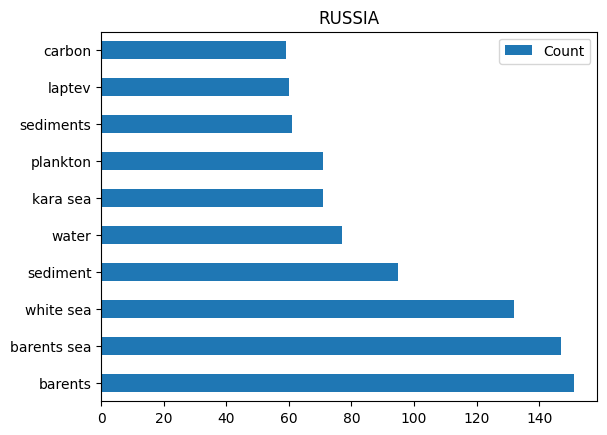

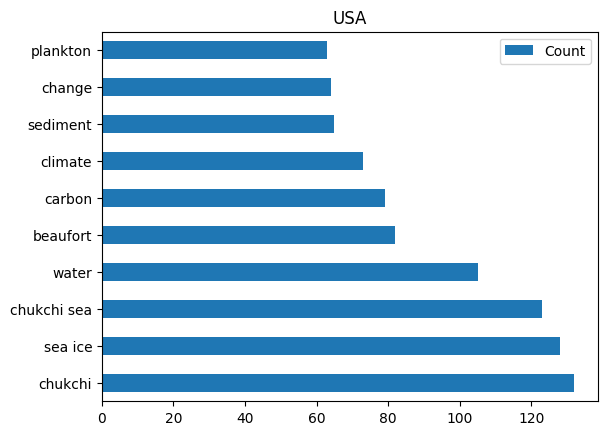

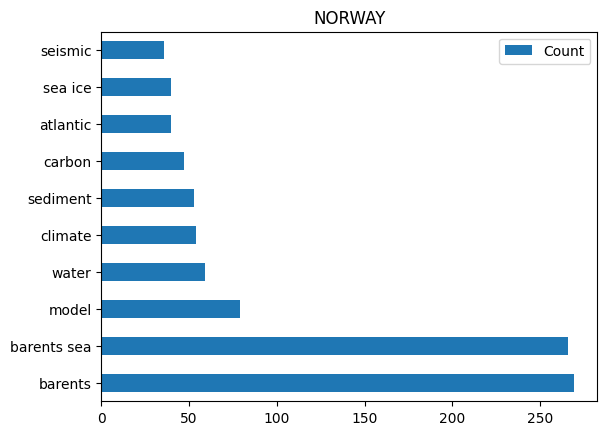

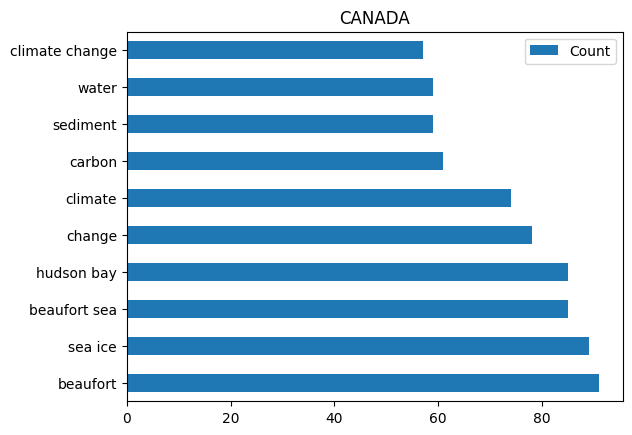

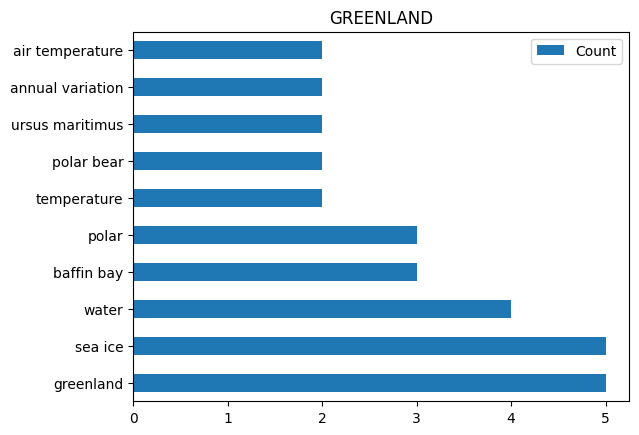

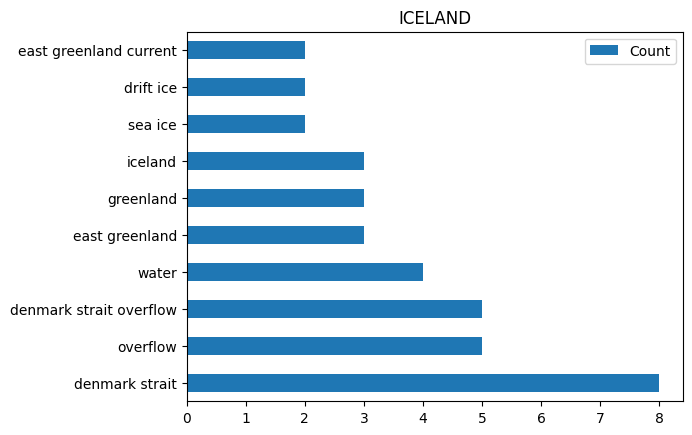

In [218]:
# temp["Count"].std()
countries_that_border = { "RUSSIA", "NORWAY", "ICELAND", "GREENLAND", "CANADA", "USA" }
for k, v in country_data.items():
    if not v.empty and k in countries_that_border:
        v.sort_values(by="Count", ascending=False).head(10).plot.barh(title=k)
# temp.sort_values(by="Count", ascending=False).head(30).plot.bar()

In [203]:
for k, v in country_data.items():

               Count
crust             10
carbon            59
zooplankton       38
sedimentation     15
sediment          95
...              ...
freshwater         9
copepod           10
communities       14
ecology           11
the arctic        13

[131 rows x 1 columns]
                          Count
western arctic               15
heat flux                    12
carbon                       79
zooplankton                  22
marine mammals               10
...                         ...
dissolved organic matter     10
ecology                      12
nutrients                    10
bering sea                   17
ocean circulation            10

[149 rows x 1 columns]
              Count
carbon           11
sediment         18
surface           9
water            27
ocean            70
ice sheet        11
barents          34
barents sea      34
modelling        11
arctic ocean     54
marine           10
glaciation        9
arctic           94
sea ice          36
greenland       

56


<Axes: ylabel='Country'>

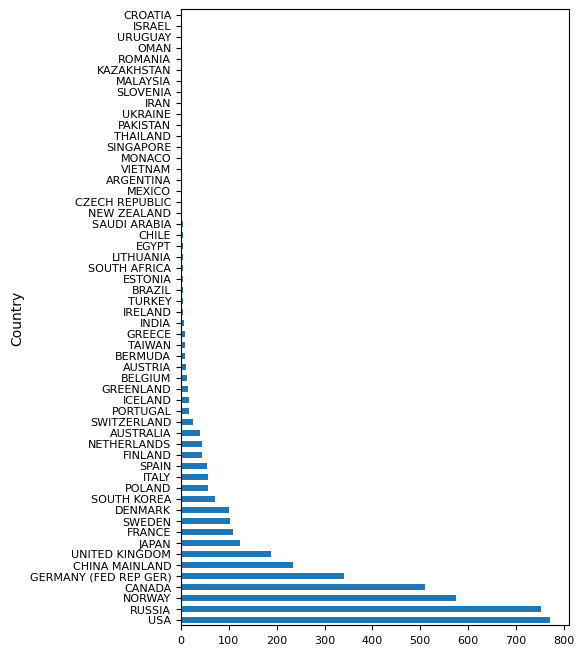

In [4]:
data = arctic_data['Country'].value_counts()
print(data.size)
# plt.bar(data)
data.plot.barh(figsize=(5, 8), fontsize=8)

In [ ]:
countries_that_border = { "RUSSIA", "NORWAY", "ICELAND", "GREENLAND", "CANADA", "USA" }
arctic_data["borders"] = arctic_data['Country'].map(lambda x: x in countries_that_border)

arctic_data["borders"].value_counts()

borders
True     2638
False    1729
Name: count, dtype: int64

Countries that border the Arctic ocean publish more papers about the Arctic ocean. I wish we had a dataset of all of the oceans' publications so we could figure out if that is statistically significant.